# Linear regression
Problem:  
Given dataset $(x_i, y_i)_{i=1}^{M}$  
We assume that $ (x, y) $ pairs were genearted with $ y = a * x + b + \epsilon $  
$ \epsilon $ - Gaussian noise

We want to find $a, b$ given observations $x, y$

Find approximation $ \hat{y}=a^*x+b^* $ that minimizes mean square error $L = \frac{1}{m}\sum_{i=1}^{M}(y_i-\hat{y})^2 = \frac{1}{m}\sum_{i=1}^{M}(y_i-(a^**x+b^*))^2$  
We need to find parameters $a, b$

# Generate data

In [2]:
import numpy as np
n_samples = 100
x = np.linspace(-5, 5, 100) # data
a = 0.5
b = -0.8
y = a * x + b + np.random.randn(n_samples)  # target / observations
# Given observed pairs (x, y), we want to find a, b that minimizes mean square error

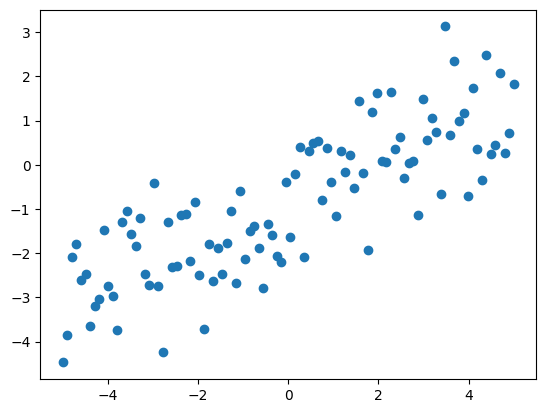

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
# TODO - Plot data 
plt.scatter(x, y)

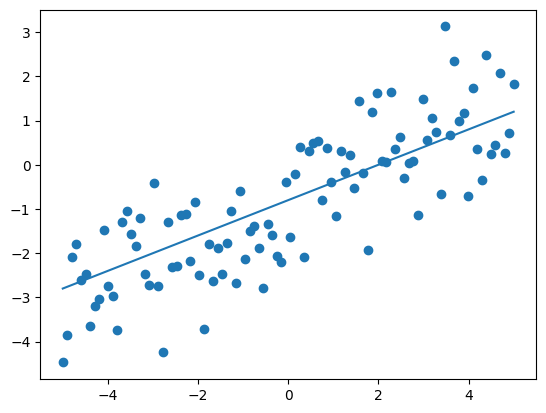

In [4]:
# TODO - Plot some random models (for random a's and b's) and gt data
plt.scatter(x, y)
x_data = np.linspace(-5, 5, 100)
y_hat = 0.4 * x - 0.8
plt.plot(x_data, y_hat)

# PyTorch datasets
Some default implementations available: https://pytorch.org/docs/stable/data.html  
For images: https://pytorch.org/docs/stable/torchvision/datasets.html#imagefolder  
**Dataset** must implement __getitem__(index) (returns indexed element) and __len__() (returns number of elements)  
We could use **TensorDataset** but let's write it

In [5]:
import torch
from torch.utils.data import Dataset

class NumpyDataset(Dataset):
    def __init__(self, data, target):
        # TODO - define class variables
        self.data = data
        self.target = target
        
    def __getitem__(self, index):
        # Anything could go here, e.g. image loading from file or a different structure
        # TODO - return data
        return torch.tensor([self.data[index]]).to(torch.float32), torch.tensor([self.target[index]]).to(torch.float32)
    
    def __len__(self):
        # TODO - return the size of the dataset
        return len(self.data)

In [69]:
dataset = NumpyDataset(x, y)

In [70]:
dataset[5]

(tensor([-4.4949]), tensor([-3.4752]))

In [46]:
x[5], y[5]

(-4.494949494949495, -3.4752296234612627)

**DataLoader** objects provide a way to efficiently iterate over datasets https://pytorch.org/docs/stable/data.html

In [71]:
from torch.utils.data import DataLoader
# Create dataloader for dataset
dataloader = DataLoader(dataset, batch_size=10, shuffle=True, num_workers=4)  # num_workers = n - how many threads in background for efficient loading

In [48]:
# We can iterate over the dataset
for xs, ys in dataloader:
    print(xs.size(), ys.size())

torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])


## PyTorch models
Pytorch models are defined as **Module** objects that need to have a **forward** method implemented that applies transformations (neural network layers) on data. https://pytorch.org/docs/stable/nn.html

In [49]:
import torch.nn as nn
class LinearModel(nn.Module):
    
    def __init__(self, input_dim):
        super(LinearModel, self).__init__()
        # TODO - define a linear model 
        self.fc = nn.Linear(input_dim, 1)
        
    def forward(self, input):
        #TODO Apply = input * A + b. A, b are parameters of nn.Linear that we want to learn
        return self.fc(input)

In [72]:
# Create model
model = LinearModel(input_dim=1)  # dimensionality of x

In [73]:
model.fc.weight, model.fc.bias

(Parameter containing:
 tensor([[0.1642]], requires_grad=True),
 Parameter containing:
 tensor([-0.2682], requires_grad=True))

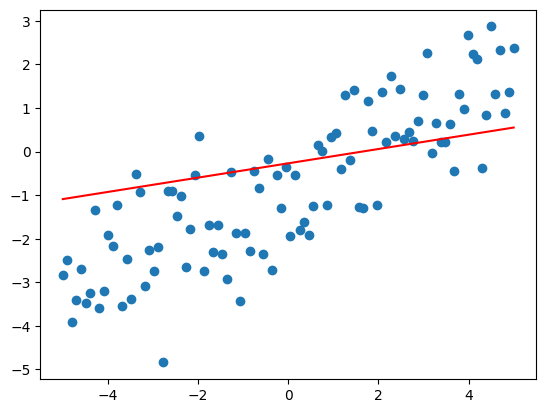

In [74]:
# TODO Plot the initial model
plt.scatter(x, y)
x_data = torch.linspace(-5, 5, 100)
y_hat = model(x_data.view(-1, 1)).flatten().detach().numpy()
plt.plot(x_data, y_hat, c="red")

In [75]:
from utils import train_mse
# TODO -  train model
train_mse(dataloader, model, n_epochs=100, device=torch.device("cuda:0"))

  0%|          | 0/100 [00:00<?, ?it/s]

In [76]:
# TODO - Print model weights
model.fc.weight, model.fc.bias

(Parameter containing:
 tensor([[0.4919]], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([-0.7230], device='cuda:0', requires_grad=True))

# Use the model for prediction

In [79]:
model.fc.weight.device

device(type='cuda', index=0)

In [80]:
model.cpu()

LinearModel(
  (fc): Linear(in_features=1, out_features=1, bias=True)
)

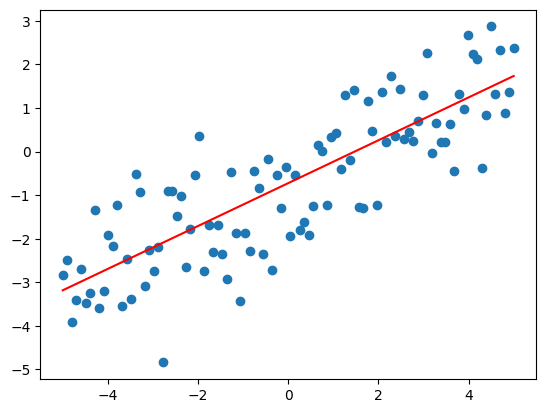

In [81]:
# TODO  - plot the final model and the GT  model
plt.scatter(x, y)
x_data = torch.linspace(-5, 5, 100)
y_hat = model(x_data.view(-1, 1)).flatten().detach().numpy()
plt.plot(x_data, y_hat, c="red")